# Nama: Mirna Rahmania Melba
# NIM: 4222301010
# Kelas: A

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [2]:
df = pd.read_csv('WineQT.csv')

In [3]:
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')


## EDA

Text(0.5, 1.0, 'Sebaran Nilai density vs alcohol')

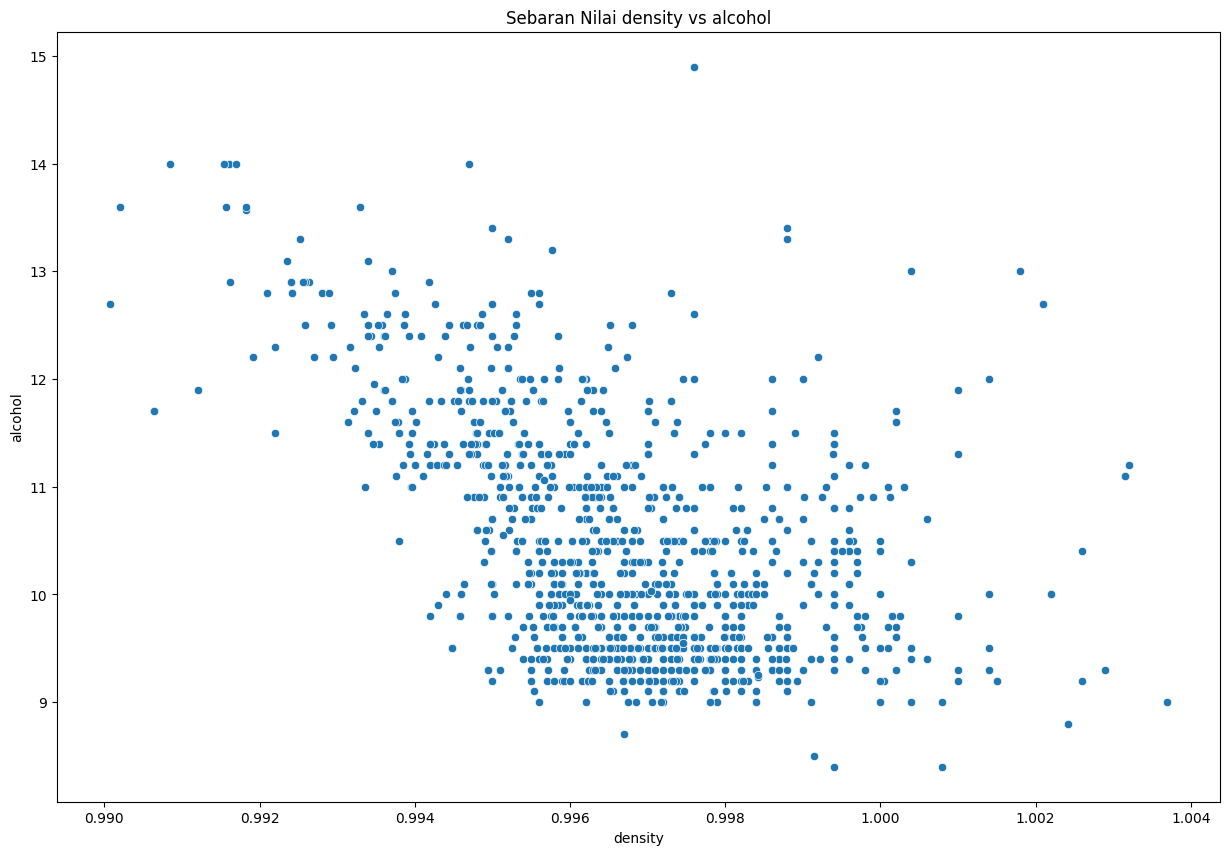

In [14]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol')
plt.title('Sebaran Nilai fixed acidity vs alcohol')

In [10]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


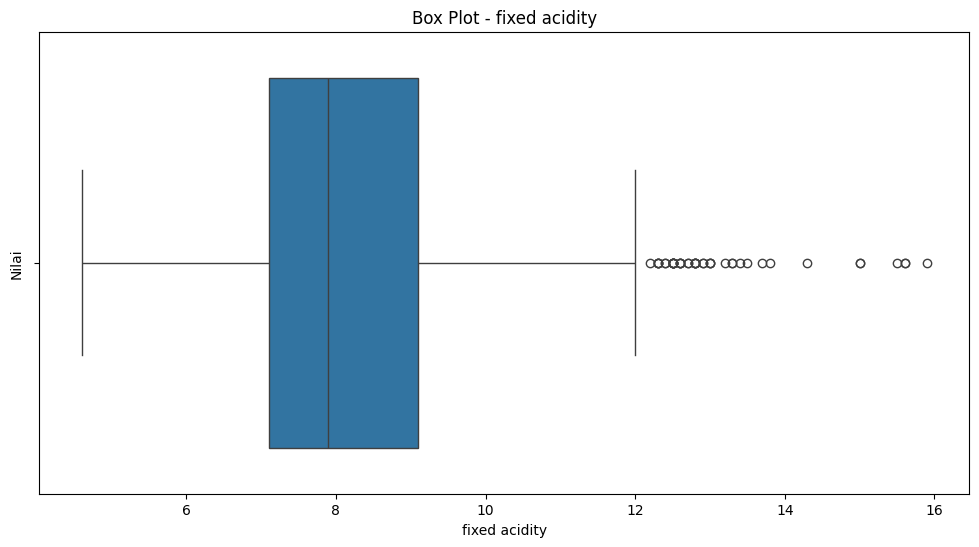

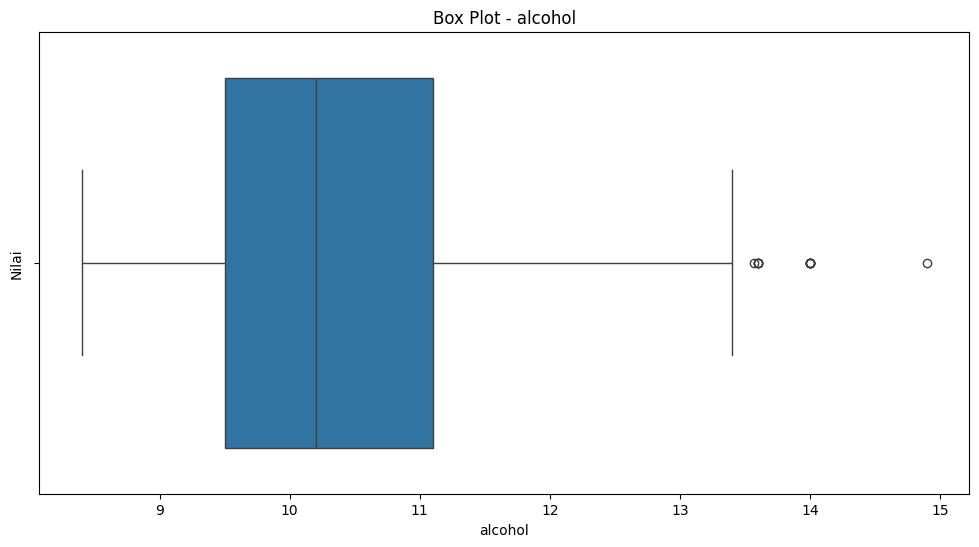

In [15]:
# Looping untuk kolom 'fixed acidity' dan 'alcohol'
columns = ['fixed acidity', 'alcohol']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

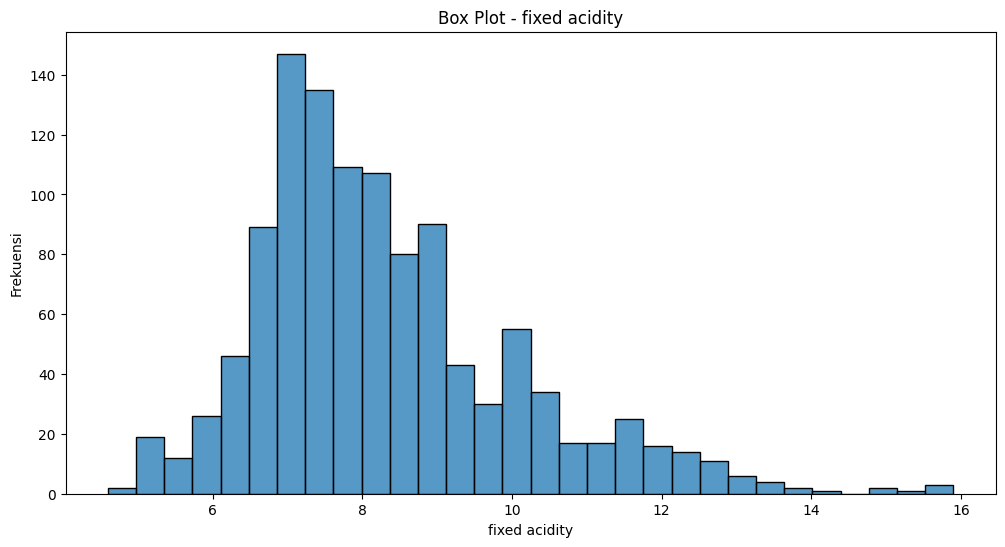

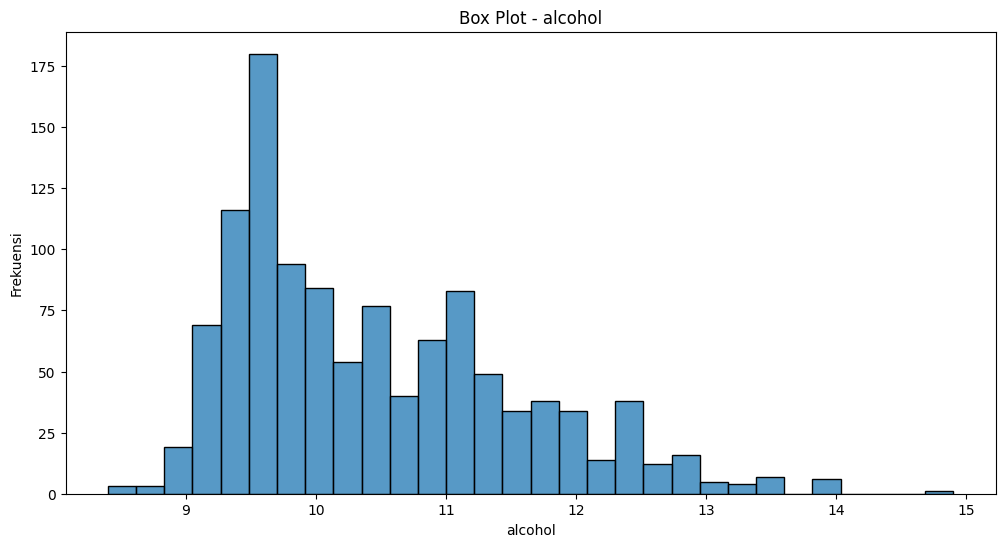

In [16]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [17]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [19]:
fitur_columns = ['fixed acidity', 'alcohol']
X = df[fitur_columns].values
y = df['quality'].values #anotator label

In [20]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,fixed acidity,alcohol
count,1.143000e+03,1.143000e+03
mean,-3.729883e-16,-1.193563e-15
std,1.000438e+00,1.000438e+00
min,-2.124483e+00,-1.887834e+00
25%,-6.933192e-01,-8.709366e-01
50%,-2.353469e-01,-2.238203e-01
75%,4.516116e-01,6.081863e-01
max,4.344377e+00,4.121103e+00


In [21]:
X_std

array([[-0.52157961, -0.96338181],
       [-0.29259344, -0.59360107],
       [-0.29259344, -0.59360107],
       ...,
       [-1.20853813,  0.05351522],
       [-1.38027776,  0.70063152],
       [-1.38027776, -0.22382033]])

In [22]:
df_scalling

,fixed acidity,alcohol
0,-0.521580,-0.963382
1,-0.292593,-0.593601
2,-0.292593,-0.593601
3,1.653789,-0.593601
4,-0.521580,-0.963382
...,...,...
1138,-1.151292,0.515741
1139,-0.865059,-0.870937
1140,-1.208538,0.053515
1141,-1.380278,0.700632


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

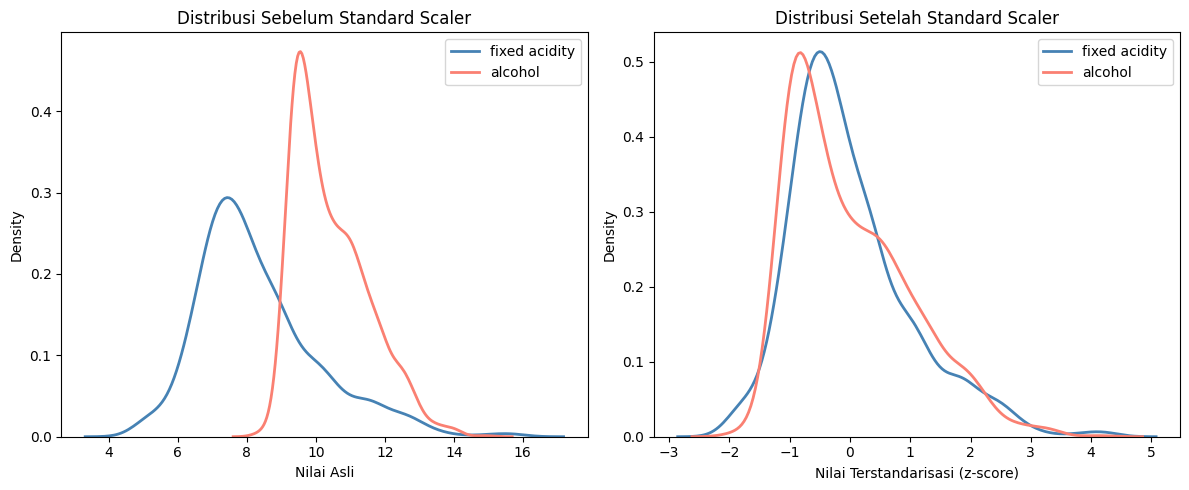

In [23]:
#cek grafik sebelum dan setelah scalling
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler (Isi dibawah ini)
sns.kdeplot(X[:, 0], ax=ax1, label='fixed acidity', color='steelblue', linewidth=2)
sns.kdeplot(X[:, 1], ax=ax1, label='alcohol', color='salmon', linewidth=2)
ax1.set_title('Distribusi Sebelum Standard Scaler')

# Plot distribusi setelah Standar Scaler (Isi dibawah ini)
sns.kdeplot(X_std[:, 0], ax=ax2, label='fixed acidity', color='steelblue', linewidth=2)
sns.kdeplot(X_std[:, 1], ax=ax2, label='alcohol', color='salmon', linewidth=2)
ax2.set_title('Distribusi Setelah Standard Scaler')

# Set x-labels
ax1.set_xlabel('Nilai Asli')
ax2.set_xlabel('Nilai Terstandarisasi (z-score)')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Sebelum Standard Scaler
Pada grafik ini nilai fitur "fixed acidity" dan "alcohol" masih berada pada rentang skala yang berbeda sehingga distribusinya belum seimbang.

2. Setelah Standard Scaler
Pada grafik ini Data telah ditransformasikan sehingga memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Bentuk distribusi kedua fitur tetap relatif sama, namun skala nilainya menjadi lebih seragam.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

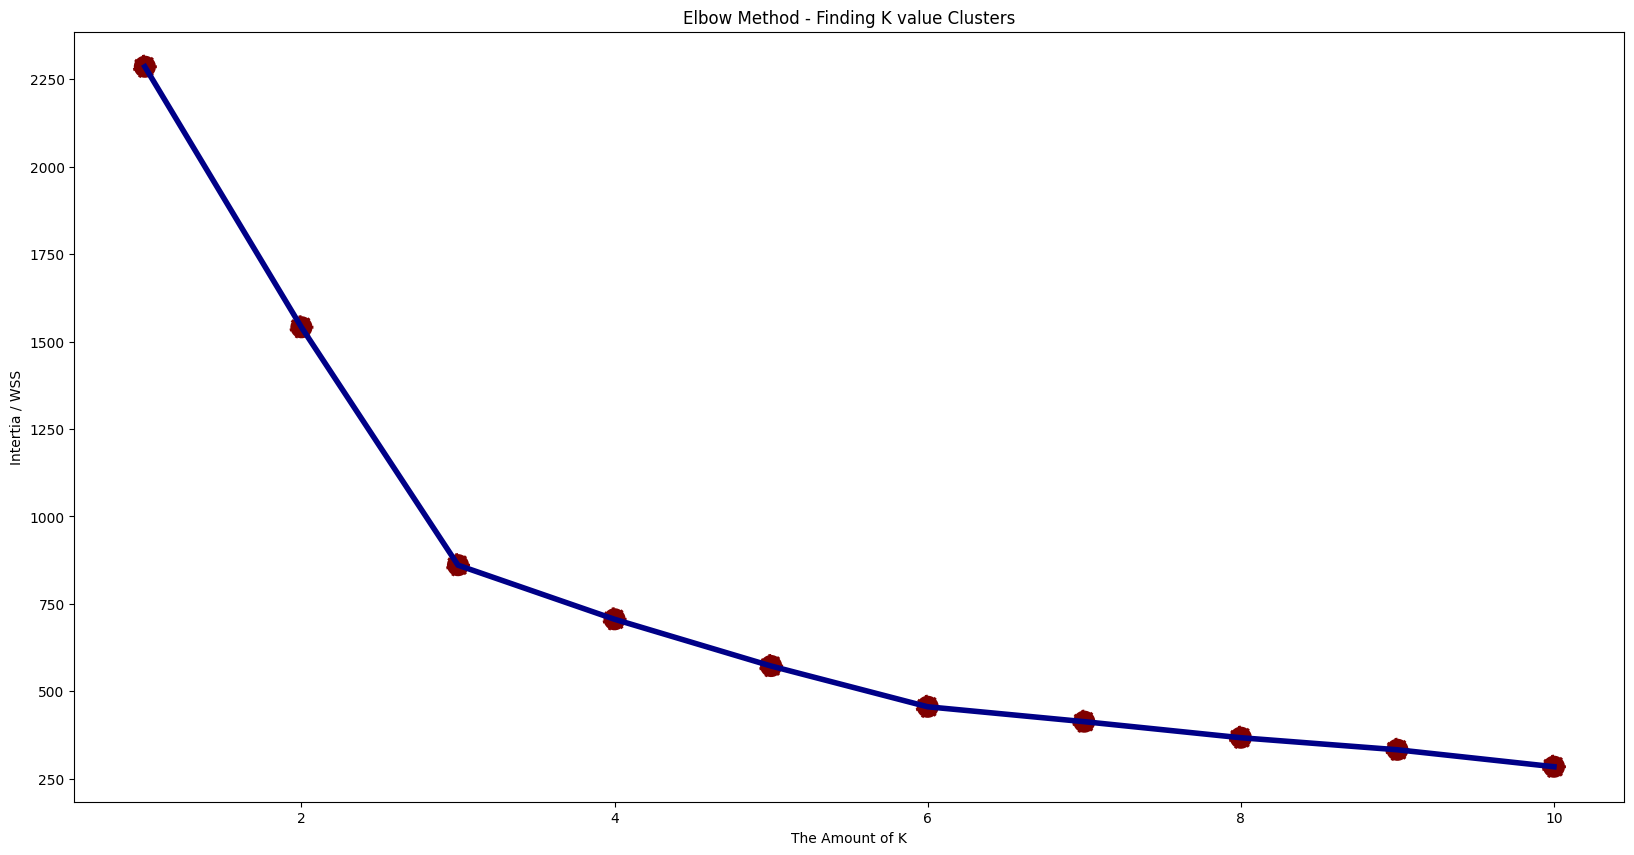

In [24]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [36]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [37]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [38]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,3
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,3
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,3
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,3
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,1


<Axes: xlabel='fixed acidity', ylabel='alcohol'>

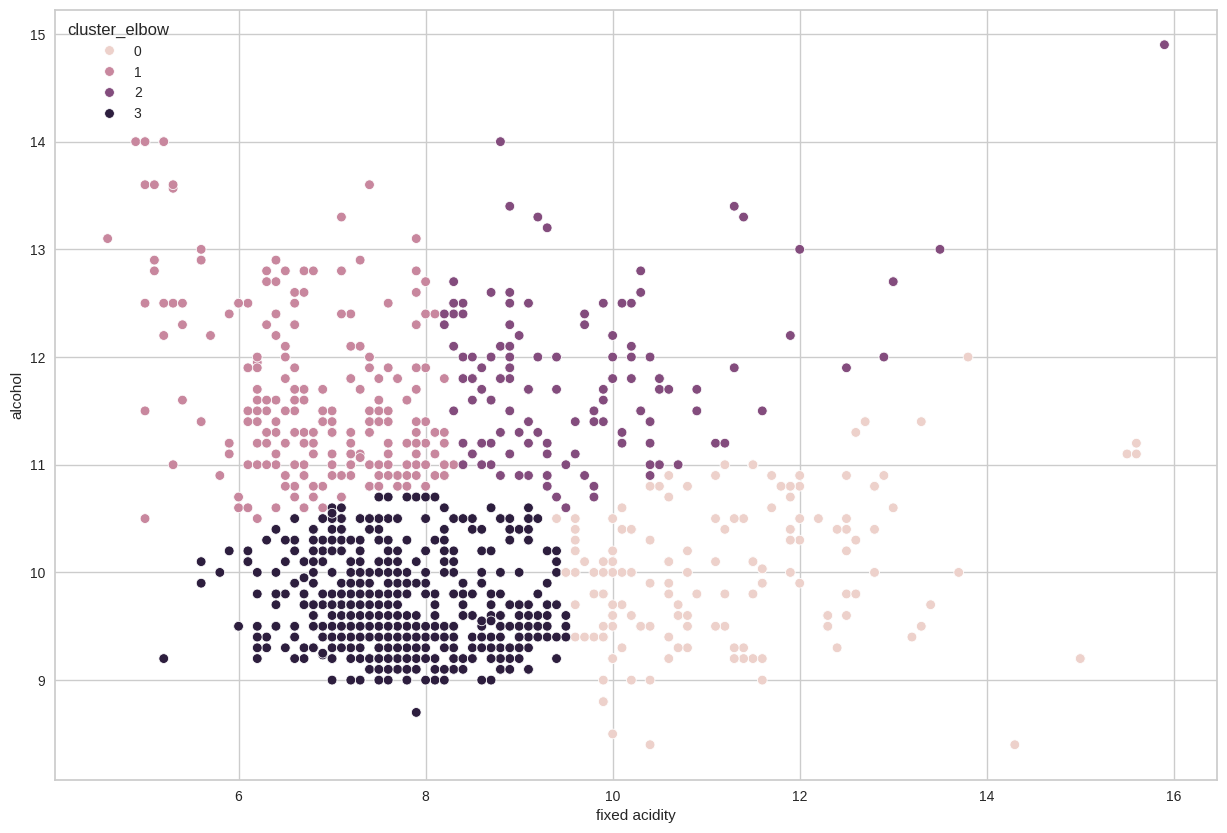

In [39]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='fixed acidity', ylabel='alcohol'>

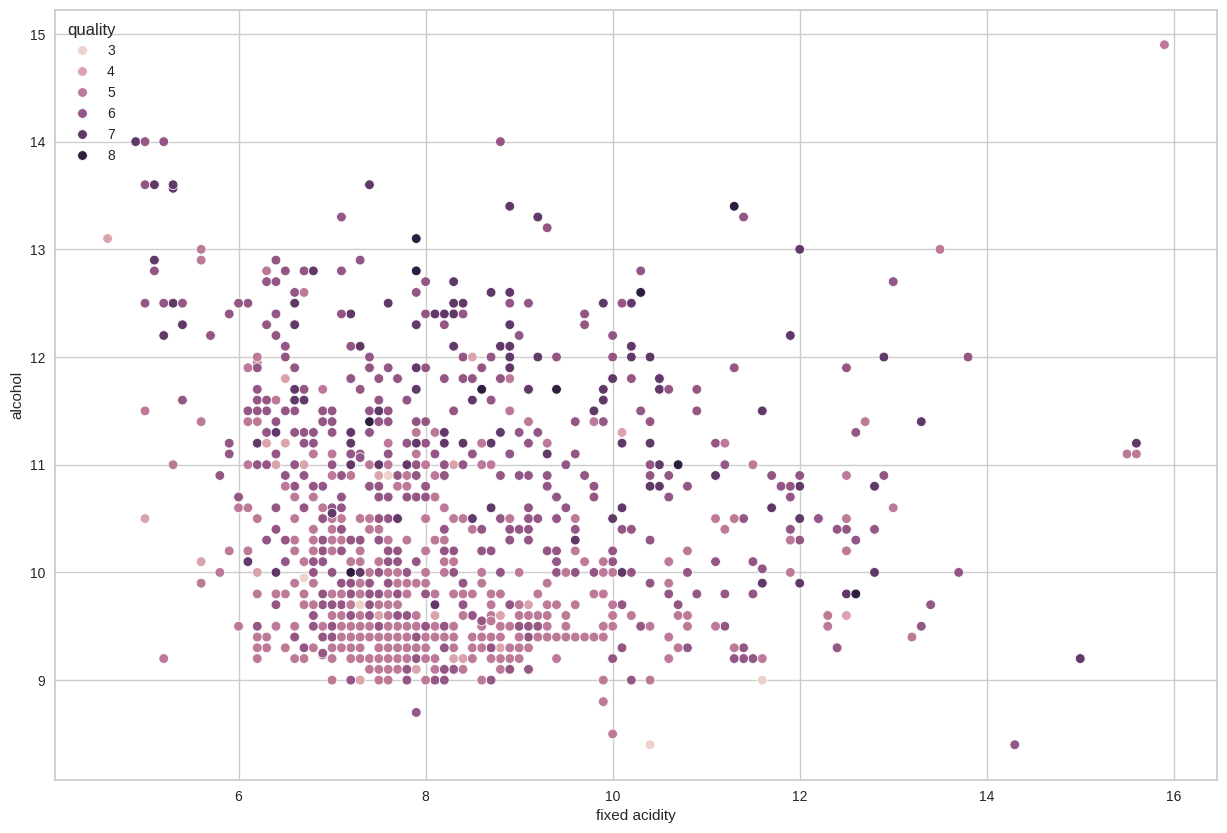

In [40]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol',hue='quality')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [41]:
!pip install yellowbrick

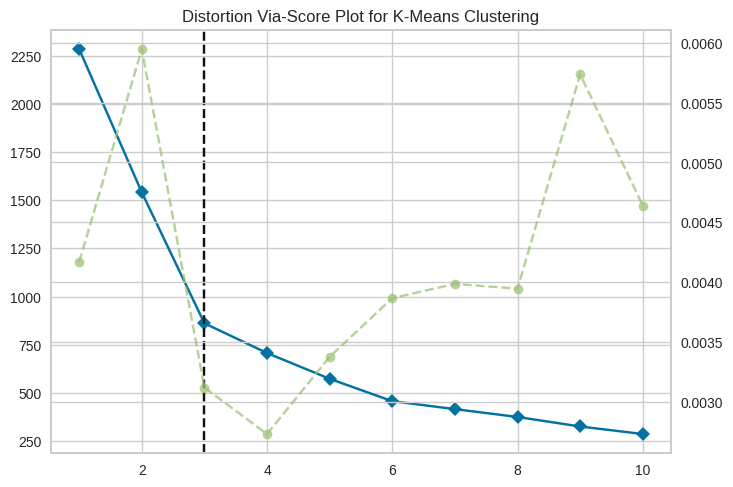

In [42]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [43]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [44]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [ ]:
df

,tinggi,berat,deskripsi,cluster_elbow,cluster_via
0,158.114332,58.364240,Normal,0,0
1,160.344026,52.560155,Normal,0,0
2,161.486080,61.934852,Normal,0,0
3,182.459297,69.042108,Slim,2,2
4,184.462584,71.341076,Slim,2,2
...,...,...,...,...,...
8883,177.296550,74.905033,Slim,2,2
8884,151.605026,81.084183,Obese,3,1
8885,158.838120,61.779766,Normal,0,0
8886,156.592981,54.047666,Normal,0,0


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

<Axes: xlabel='fixed acidity', ylabel='alcohol'>

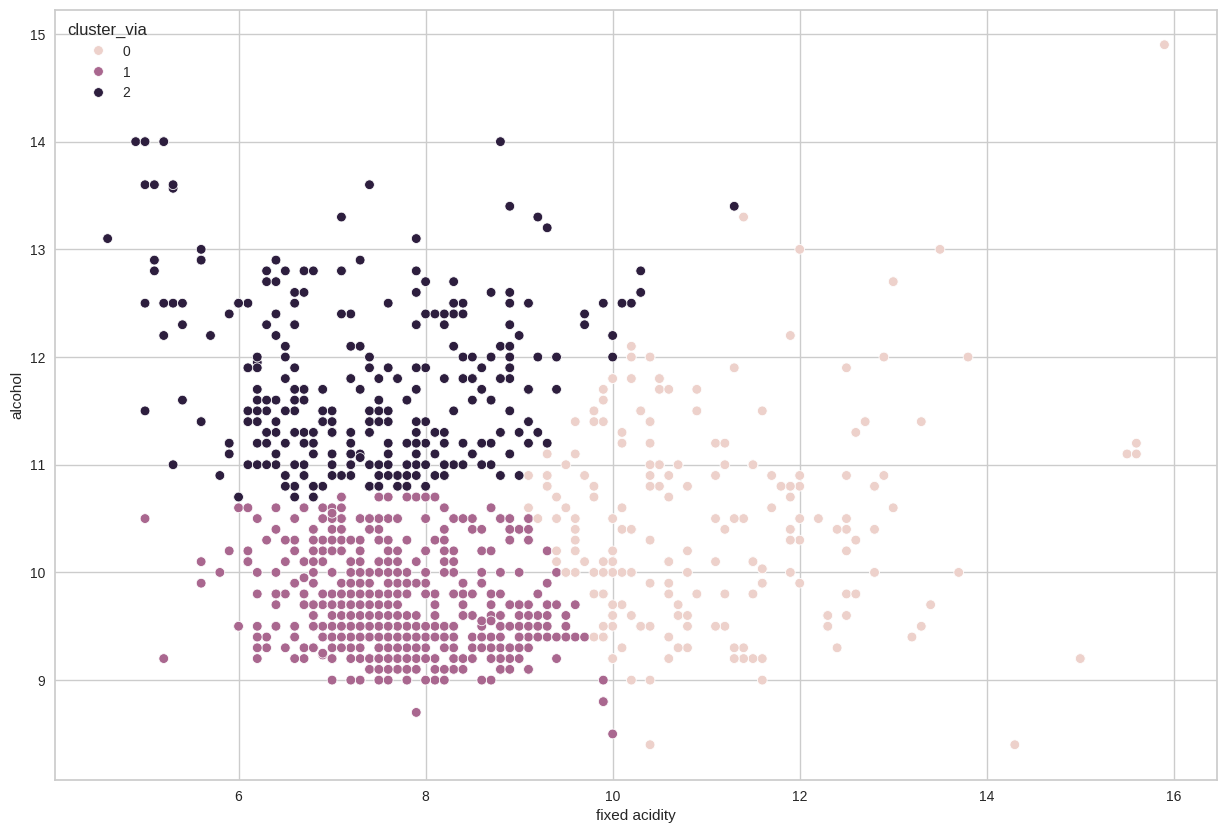

In [45]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='cluster_via')

### Bandingkan dengan label anotator

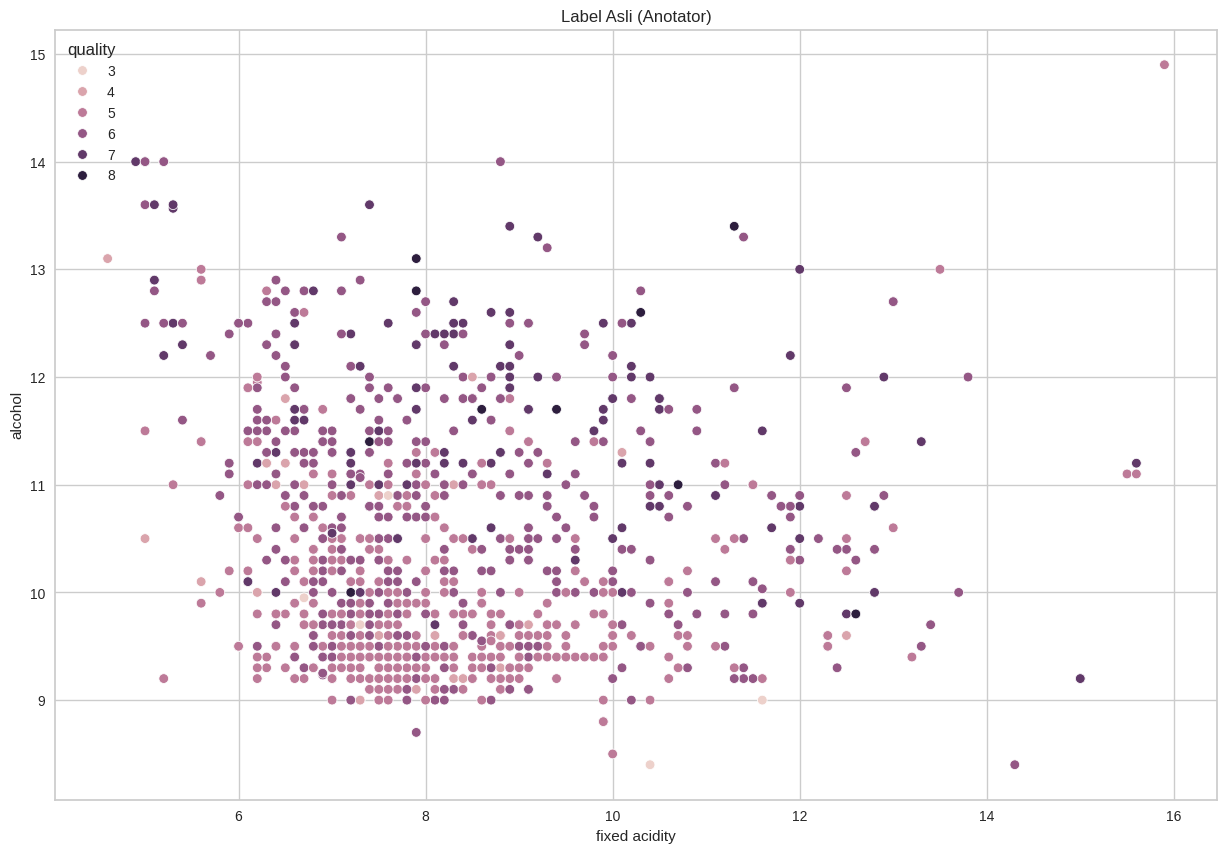

In [46]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol', hue='quality')
plt.title('Label Asli (Anotator)')
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
Hasil evaluasi terlihat bahwa:

Hasil clustering K-Means menunjukkan pola pengelompokan data yang cukup baik, tetapi belum sepenuhnya memenuhi label kualitas yang diberikan pada awalnya. Ini disebabkan oleh fakta bahwa fitur "fixed acidity" dan "alcohol" masih memiliki overlap antar kelas, yang berarti bahwa beberapa jenis wine termasuk dalam kelompok yang sama.

### Thank you :)